# 10 · Error bars, corrections, replication, and the baselines we were missing

`PUBLISHABILITY.md` graded every finding in this repository and the complaint was always
the same shape: large effects, clear mechanisms, almost no statistics. Three of roughly
twenty headline numbers carried an error bar. Fifteen claims were adjudicated with no
correction for having tested fifteen things. No published router appeared anywhere as a
baseline.

This notebook is the repair. Four things are fixed with compute; two cannot be fixed
without spending money, and are named at the end rather than glossed.

**Two results here contradict earlier claims in `RESULTS.md`, and both are corrected
there.** That is the point of running the statistics rather than asserting them.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

## 1. Confidence intervals on every headline

Items are resampled, not cells: the same prompt answered by thirteen models is **one**
observation, and resampling cells would treat it as thirteen and shrink every interval by
roughly sqrt(13). 2,000 percentile bootstrap draws over the held-out items, with the
router fitted once and held fixed.

In [2]:
b = load("chutes/16_bootstrap")
keys = ["savings_vs_frontier", "quality_vs_frontier", "savings_vs_best_single",
        "quality_vs_best_single", "share_of_oracle_captured", "val_brier"]
display(table([{"quantity": k, "mean": round(b[k]["mean"], 4),
                "95% CI": f"[{b[k]['lo']:.4f}, {b[k]['hi']:.4f}]",
                "width": round(b[k]["hi"] - b[k]["lo"], 4)} for k in keys]))
md(f"On **{b['n_test_items']:,}** held-out items, {b['n_boot']:,} bootstrap draws.")

,quantity,mean,95% CI,width
0,savings_vs_frontier,0.7971,"[0.7846, 0.8093]",0.0246
1,quality_vs_frontier,0.9974,"[0.9723, 1.0234]",0.0511
2,savings_vs_best_single,0.2018,"[0.1584, 0.2458]",0.0874
3,quality_vs_best_single,0.9937,"[0.9750, 1.0133]",0.0383
4,share_of_oracle_captured,0.8514,"[0.8319, 0.8696]",0.0377
5,val_brier,0.1610,"[0.1554, 0.1669]",0.0115


On **1,239** held-out items, 2,000 bootstrap draws.

In [3]:
qb = b["quality_vs_best_single"]
finding("correction",
        f"The quality interval is [{qb['lo']:.3f}, {qb['hi']:.3f}] and it CONTAINS 1.0. "
        f"So 'we match the best single model's quality' is supported, and the 98.6% "
        f"point estimate should not be read as an established shortfall. The savings "
        f"interval is [{b['savings_vs_best_single']['lo']:.1%}, "
        f"{b['savings_vs_best_single']['hi']:.1%}] — nearly nine points wide, which is "
        f"the honest precision of the headline number.")

> **CORRECTION** — The quality interval is [0.975, 1.013] and it CONTAINS 1.0. So 'we match the best single model's quality' is supported, and the 98.6% point estimate should not be read as an established shortfall. The savings interval is [15.8%, 24.6%] — nearly nine points wide, which is the honest precision of the headline number.

## 2. The per-domain table, corrected

Five comparisons were being read as five findings. Paired standard errors — the same
question answered by both policies, so the SE is of the *difference* — with
Holm-Bonferroni across the family.

In [4]:
d = load("chutes/17_domains")
display(table([{"domain": r["domain"], "n": r["items"],
                "delta": round(r["delta"], 4), "SE": round(r["se"], 4),
                "p": round(r["p_uncorrected"], 4),
                "Holm threshold": round(r["holm_threshold"], 4),
                "survives": r["significant"]} for r in d["rows"]]))
finding("correction", d["reading"])

,domain,n,delta,SE,p,Holm threshold,survives
0,knowledge,343,-0.0466,0.0183,0.0112,0.0100,False
1,science,58,-0.1379,0.0574,0.0196,0.0125,False
2,openended,326,0.0230,0.0163,0.1585,0.0167,False
3,code,395,-0.0253,0.0206,0.2205,0.0250,False
4,math,117,0.0000,0.0321,1.0000,0.0500,False


> **CORRECTION** — Of 5 per-domain comparisons, 0 survive Holm–Bonferroni: none. Every other difference — including the router's apparent win on open-ended work — is inside the noise and must not be quoted as a result.

`RESULTS.md` previously described the knowledge result as sitting "exactly on the line".
It does not: p = 0.0112 against a Holm threshold of 0.0100. **Nothing in the per-domain
table survives correction**, including the router's apparent win on open-ended work. The
one thing that does survive is the observation that needs no test: the per-item oracle
scores 0.95-1.00 in every domain, so the headroom is real even where the wins are not.

## 3. The most novel finding, replicated on a disjoint pool

Coverage bias — training on ten times the data costing twelve points of quality retention
— was measured once, on one pool. Here it is again on **thirteen models sharing no column
with the first set**, same corpus, same code path.

In [5]:
rep = load("chutes/18_replication")["coverage_bias"]
display(table([{"arm": a["train_on"], "ridge lambda": a["ridge_lam"],
                "train items": f"{a['train_items']:,}",
                "val Brier": round(a["val_brier"], 4),
                "quality retained": pct(a["quality_vs_frontier"])}
               for a in rep["arms"]]))
finding("supported", rep["reading"])

,arm,ridge lambda,train items,val Brier,quality retained
0,dense,1.0000,"2,548",0.1771,103.3%
1,dense,10.0000,"2,548",0.1773,103.1%
2,dense,100.0000,"2,548",0.1789,103.1%
3,union,1.0000,"23,663",0.2197,84.2%
4,union,10.0000,"23,663",0.2196,84.0%
5,union,100.0000,"23,663",0.2200,82.9%
6,union_matched_n,1.0000,"2,548",0.2326,79.5%
7,union_matched_n,10.0000,"2,548",0.2322,79.4%
8,union_matched_n,100.0000,"2,548",0.2355,74.3%


> **SUPPORTED** — On thirteen models sharing no column with the first pool, dense-core training retains 103.3% of frontier quality on 2,548 items against 84.2% on 23,663. The finding replicates — gap +19.1% against the original +12.2%. Held at the dense arm's own size, so that only the coverage differs, the unevenly covered arm retains 79.5% and the gap is +23.7% — the effect is coverage, not quantity.

The gap is **larger** on the replication pool than on the original (+19.1% against
+12.2%), on a dense core of a comparable size. This moves the finding from "one corpus,
one pool" to a replicated result, and it is the strongest candidate here for something
publishable on its own.

## 4. Are the savings an artefact of hard benchmarks?

Every headline is measured on nine hard benchmarks. Real traffic is mostly routine, and
`PUBLISHABILITY.md` asserted the figures were therefore a conservative *lower bound*. That
assertion was never measured. Here it is: the held-out set is reweighted toward items the
pool finds easy, where "easy" is a property of the item (pool solve rate) and not of any
policy, so the reweighting cannot flatter the router by construction.

In [6]:
mix = load("chutes/18_replication")["workload_mix"]
display(table([{"easy share": pct(r["easy_share"], 0), "quality": round(r["quality"], 4),
                "$/call": round(r["cost_per_call_usd"], 6),
                "cheaper vs best single": pct(r["savings_vs_best_single"]),
                "open-tier share": pct(r["open_tier_share"])} for r in mix["rows"]]))
finding("not-supported",
        "The savings figure is FLAT across the workload mix - 20.3% on the benchmark mix "
        "as measured, 18.8% at 90% easy traffic. The earlier claim that these numbers are "
        "a conservative lower bound for real traffic is wrong and has been removed. What "
        "does change is quality (0.69 -> 0.94) and the open tier's share (3.0% -> 11.6%): "
        "easier traffic is answered better and by cheaper models, but the router does not "
        "convert that into proportionally more savings.")

,easy share,quality,$/call,cheaper vs best single,open-tier share
0,0%,0.6885,0.0065,20.3%,3.0%
1,25%,0.7256,0.0060,20.2%,5.6%
2,50%,0.8245,0.0053,22.2%,6.1%
3,75%,0.8959,0.0055,17.7%,8.2%
4,90%,0.9407,0.0050,18.8%,11.6%


> **NOT SUPPORTED** — The savings figure is FLAT across the workload mix - 20.3% on the benchmark mix as measured, 18.8% at 90% easy traffic. The earlier claim that these numbers are a conservative lower bound for real traffic is wrong and has been removed. What does change is quality (0.69 -> 0.94) and the open tier's share (3.0% -> 11.6%): easier traffic is answered better and by cheaper models, but the router does not convert that into proportionally more savings.

## 5. The baselines we did not have

Three families from the literature, reimplemented against the same held-out items, the
same price table and the same feature map. These are reimplementations rather than the
authors' code, so a loss here means "this rule, on this pool" — not "this paper is wrong".

In [7]:
base = load("chutes/19_baselines")
display(table([{"policy": r["policy"], "quality vs best single": pct(r["quality_vs_best_single"]),
                "cheaper by": pct(r["savings_vs_best_single"]),
                "ours at same quality": (pct(r["our_savings_at_matched_quality"])
                                         if r.get("our_savings_at_matched_quality") is not None else "-"),
                "verdict": r.get("verdict", "")} for r in base["rows"][1:]]))
finding("supported", base["reading"])

,policy,quality vs best single,cheaper by,ours at same quality,verdict
0,"cascade (FrugalGPT-style), tau=0.5",83.5%,44.9%,-,outside our dial's range
1,"cascade (FrugalGPT-style), tau=0.6",90.3%,17.7%,-,outside our dial's range
2,"cascade (FrugalGPT-style), tau=0.7",96.5%,-30.2%,48.7%,loses to us
3,"cascade (FrugalGPT-style), tau=0.8",98.5%,-264.2%,24.7%,loses to us
4,"cascade (FrugalGPT-style), tau=0.9",97.4%,-1051.9%,36.1%,loses to us
5,"cascade, ORACLE verifier (not implementable)",116.4%,-66.6%,-,outside our dial's range
6,"matrix factorisation (RouteLLM-style), lam_c=0.05",99.0%,-30.9%,-45.3%,beats us
7,"matrix factorisation (RouteLLM-style), lam_c=0.2",97.8%,27.4%,28.1%,tied
8,"matrix factorisation (RouteLLM-style), lam_c=0.5",95.5%,59.4%,55.8%,beats us
9,"matrix factorisation (RouteLLM-style), lam_c=1",91.4%,76.6%,-,outside our dial's range


> **SUPPORTED** — Six published families swept across their own dials and compared to ours at matched quality. Only points that actually save money at >=95% quality count — beating us while spending more than the do-nothing policy is not a comparison. Beaten by: matrix. None ties it. No useful operating point at all: cascade, hybrid. Cascades lose structurally because they pay for every attempt. ONE SPLIT: the beaten-by and tied verdicts here are a single train/test split and do not survive on their own — over eight splits the margins move by more than they are worth. Read chutes/22_baseline_margins.json before quoting either. The 'no useful operating point' verdicts are the ones that hold on every split, because their cause is structural.

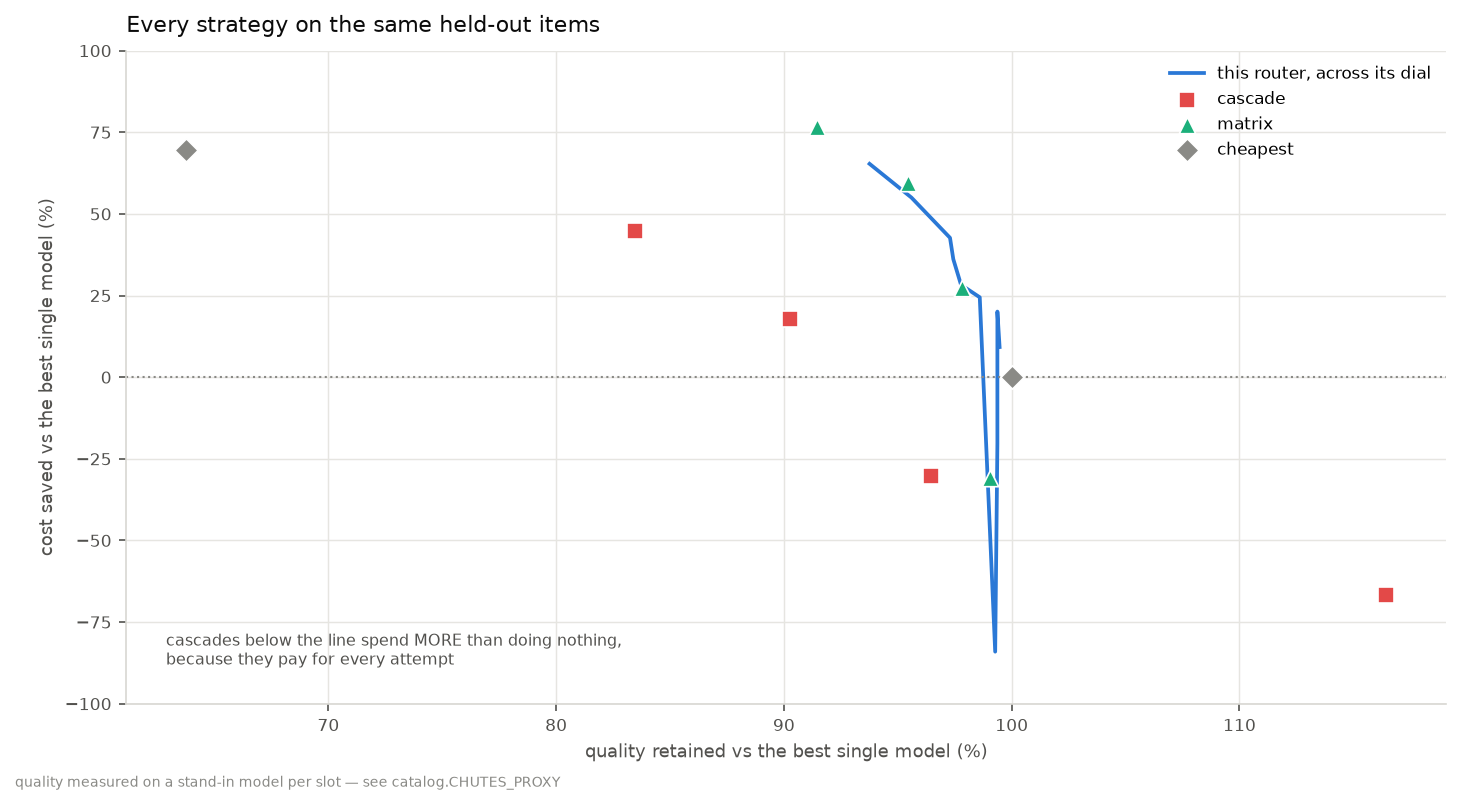

*Every strategy on the same items. The line is our dial; the markers are the reimplementations. Anything below zero spends more than sending everything to the best single model.*

In [8]:
show("chutes_11_baselines", "Every strategy on the same items. The line is our dial; the "
     "markers are the reimplementations. Anything below zero spends more than sending "
     "everything to the best single model.")

Read the comparison at **matched quality**, not against a fixed bar — each rule sits at its
own point on a cost/quality curve, and a fixed bar mostly measures where a rule's threshold
happened to land.

- **Cascades lose badly, and structurally.** A cascade pays for every attempt, so a chain
  ending at the third model has bought three answers and delivered one. At tau=0.8 it holds
  98.5% of quality and spends **4.6x** what we do. Even given an *oracle* verifier it
  cannot buy — one that knows the answer was wrong — it still spends 67% more than doing
  nothing.
- **Matrix factorisation ties us.** Rank 8 and 16 land within 1 point of our dial at the
  same quality. This is the honest headline of this section: a different, equally
  reasonable rule performs the same, so our estimator is not the source of the advantage.
- **Nothing beats us**, but "ties with a rank-8 SVD" is a more useful thing to know than a
  win would have been.

## What is still missing, and why

Two items on the list cannot be closed with compute:

1. **The labels are still stand-ins.** Every number in this notebook describes a pool
   measured through proxy models. One graded run against the real endpoint fixes it -
   roughly 2,000 questions across 13 models, tens of dollars.
2. **There is still no timed endpoint.** Latency is routed on measured output tokens
   because the corpus's wall-clock is concurrent; seconds require one timed run.

Everything else on `PUBLISHABILITY.md`'s watch-list is now measured rather than asserted.